# __________ *📌 Loan Approval Prediction using Machine Learning*_______

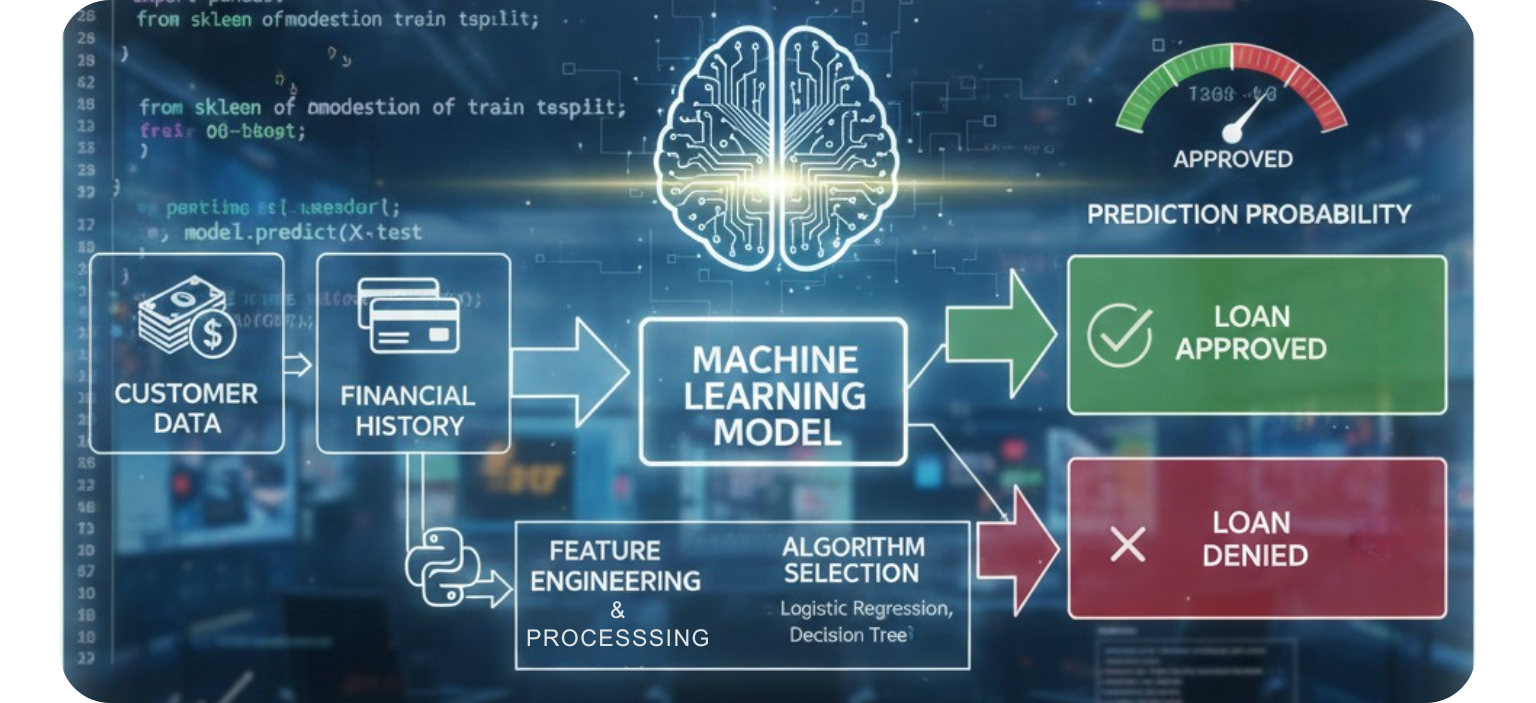

-----

### 🤖 Project Description

"An end-to-end Machine Learning project that analyzes loan applicants data and builds a predictive model to accurately classify loan approvals using Random Forest."


##### 🔹 Objectives of the Project:

- Perform Exploratory Data Analysis (EDA) to understand patterns in loan approval

- Data Cleaning, handling outliers

- Perform feature engineering and encoding of categorical variables

- Visualize key insights using: Bar charts, Boxplots, Histograms, Scatter plots, Correlation heatmaps

- Compare machine learning models: Logistic Regression, Decision Tree, Random Forest

- Select and build the best-performing model (Random Forest)

- Use the trained model to predict loan approval for new applicants


##### 🚀 Skills Demonstrated in This Project

- Python (Pandas, NumPy, Matplotlib, Seaborn)
- Data Cleaning & EDA
- Feature Engineering
- Machine Learning with Scikit-learn
- Model Evaluation (Accuracy, Confusion Matrix, Classification Report)

------

### 📊 Dataset Description

This dataset represents real-world loan application data used to analyze customer profiles and predict whether a loan will be approved or rejected.
Each row represents one applicant, and the columns include profile, financial, and asset-related information.

##### Key Features in the Dataset:

- no_of_dependents – Number of dependents the applicant has
- education – Graduate / Not Graduate
- self_employed – Whether the applicant is self-employed
- income_annum – Annual income of the applicant
- loan_amount – Loan amount requested
- loan_term – Loan repayment time (years)
- cibil_score – Credit score indicating creditworthiness
- residential_assets_value – Value of residential assets
- commercial_assets_value – Value of commercial assets
- luxury_assets_value – Value of luxury assets
- bank_asset_value – Bank balance / financial assets
- loan_status (Target variable) – Approved (1) or Rejected (0)

--------

## Import Python Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Load Dataset

df = pd.read_csv("C:\\Users\\USER\\Desktop\\praveen\\loan_approval_prediction\\loan_approval_dataset.csv")

In [9]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


------

# 🔥 Section 1: Data Understanding (Warm-up)

In [10]:
# Data Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [11]:
# Summary Statistics

df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [12]:
# Change the values of all numeric columns of the dataframe upto 2 point decimal.

pd.set_option('display.float_format', '{:.2f}'.format)

In [13]:
# Summary Statistics

df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [14]:
# How many loan applications are there in this dataset?

df['loan_id'].count()

np.int64(4269)

In [15]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [20]:
# What percentage of applicants get loan approved vs rejected?

df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [21]:
# Strips the white space from both sides


df.columns = df.columns.str.strip()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [23]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [24]:
df['education'] = df['education'].str.strip()

df['self_employed'] = df['self_employed'].str.strip()

df['loan_status'] = df['loan_status'].str.strip()

In [25]:
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [26]:
# What percentage of applicants get loan approved vs rejected?

df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [27]:
df['loan_status'].value_counts(normalize = True) * 100

loan_status
Approved   62.22
Rejected   37.78
Name: proportion, dtype: float64

In [28]:
# Are there missing values in the dataset? Which columns are most affected?

df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [29]:
# What are the data types of each feature (categorical vs numerical)?

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [30]:
# Change datatype of 'loan_id' column

df['loan_id'] = df['loan_id'].astype(str)

In [31]:
# What are the data types of each feature (categorical vs numerical)?

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   object
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


In [32]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


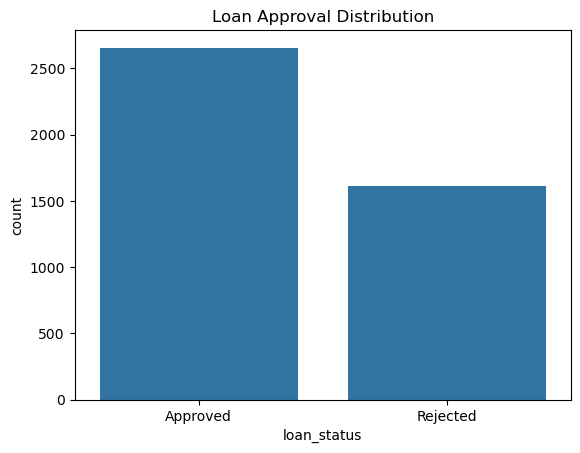

In [33]:
# Is the dataset balanced or imbalanced for loan approval?

sns.countplot(x = 'loan_status', data = df)
plt.title("Loan Approval Distribution")

plt.show()

----------

----------

# 📊 Section 2: Exploratory Data Analysis (EDA)

----------

### 1. Does Employment Type affect loan approval?

In [34]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [35]:
df['self_employed'].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [36]:
emp_status = df.groupby(['self_employed', 'loan_status'])['loan_status'].count().unstack()

emp_status

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


In [37]:
emp_status['Total'] = emp_status['Approved'] + emp_status['Rejected']

In [38]:
emp_status

loan_status,Approved,Rejected,Total
self_employed,,,
No,1318,801,2119
Yes,1338,812,2150


In [39]:
emp_status['Approval_%'] = emp_status['Approved'] / emp_status['Total'] * 100

In [40]:
emp_status

loan_status,Approved,Rejected,Total,Approval_%
self_employed,,,,
No,1318,801,2119,62.20
Yes,1338,812,2150,62.23


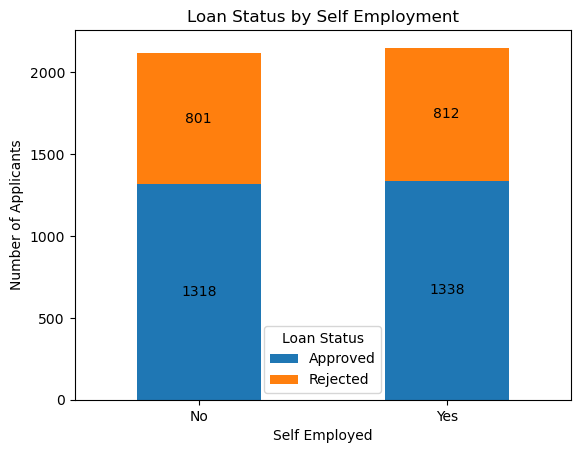

'This stacked bar chart clearly shows that approval rates are almost identical for self-employed and \nnon self-employed applicants, meaning employment type does not strongly influence approval.'

In [41]:
# Plot stacked bar chart
# ax - matplotlib axes object (the chart area)

ax = emp_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True)

plt.title("Loan Status by Self Employment")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

for container in ax.containers:
    ax.bar_label(container, label_type = 'center')

plt.show()

"""This stacked bar chart clearly shows that approval rates are almost identical for self-employed and 
non self-employed applicants, meaning employment type does not strongly influence approval."""

----------

### 2. Do graduates get higher approval rates than non-graduates?

In [42]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [43]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [44]:
education_status = df.groupby(['education', 'loan_status'])['loan_status'].count().unstack()

education_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [45]:
education_status['Total'] = education_status['Approved'] + education_status['Rejected']

In [46]:
education_status

loan_status,Approved,Rejected,Total
education,,,
Graduate,1339,805,2144
Not Graduate,1317,808,2125


In [47]:
education_status['Approval_%'] = education_status['Approved'] / education_status['Total'] * 100

In [48]:
education_status

loan_status,Approved,Rejected,Total,Approval_%
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


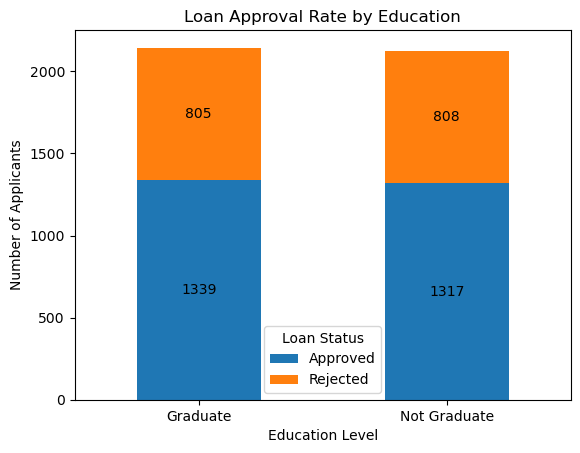

'This stacked bar chart clearly shows that approval rates are almost identical for graduate and \nnon-graduate applicants, meaning education does not strongly influence approval.'

In [49]:
# Plot stacked bar chart

ax1 = education_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True)

plt.title("Loan Approval Rate by Education")
plt.ylabel("Number of Applicants")
plt.xlabel("Education Level")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")

for container in ax1.containers:
    ax1.bar_label(container, label_type = 'center')


plt.show()

"""This stacked bar chart clearly shows that approval rates are almost identical for graduate and 
non-graduate applicants, meaning education does not strongly influence approval."""

--------

### 3. Does having more dependents reduce approval chances?

In [50]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [51]:
df['no_of_dependents'].value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

In [52]:
dep_status = df.groupby(['no_of_dependents', 'loan_status'])['loan_status'].count().unstack()

dep_status

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [53]:
dep_status['Total'] = dep_status['Approved'] + dep_status['Rejected']

In [54]:
dep_status

loan_status,Approved,Rejected,Total
no_of_dependents,,,
0,457,255,712
1,430,267,697
2,441,267,708
3,457,270,727
4,465,287,752
5,406,267,673


In [55]:
dep_status['Approval_%'] = dep_status['Approved'] / dep_status['Total'] * 100

In [56]:
dep_status

loan_status,Approved,Rejected,Total,Approval_%
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


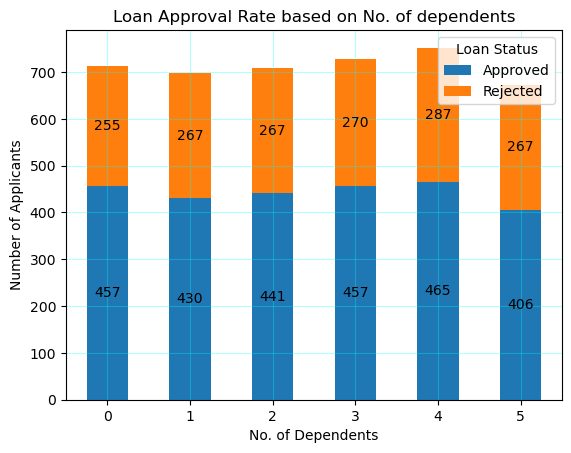

'"The approval rate generally decreases as the number of dependents increases, \nindicating that higher financial responsibility reduces the likelihood of loan approval.'

In [57]:
# Plot stacked bar chart

ax2 = dep_status[['Approved', 'Rejected']].plot( kind = 'bar', stacked = True)

plt.title("Loan Approval Rate based on No. of dependents")
plt.ylabel("Number of Applicants")
plt.xlabel("No. of Dependents")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
plt.grid(True, color = 'cyan', alpha = 0.3)


for container in ax2.containers:
    ax2.bar_label(container, label_type = 'center')

plt.show()

""""The approval rate generally decreases as the number of dependents increases, 
indicating that higher financial responsibility reduces the likelihood of loan approval."""

--------

### 4. What is the relationship between applicant income and loan approval?

In [58]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [59]:
df['income_annum'].describe()

count      4269.00
mean    5059123.92
std     2806839.83
min      200000.00
25%     2700000.00
50%     5100000.00
75%     7500000.00
max     9900000.00
Name: income_annum, dtype: float64

In [60]:
x = df.groupby(by = ['loan_status']).mean(numeric_only = True)['income_annum']

x

loan_status
Approved   5025903.61
Rejected   5113825.17
Name: income_annum, dtype: float64

In [61]:
type(x)

pandas.core.series.Series

<Axes: xlabel='loan_status'>

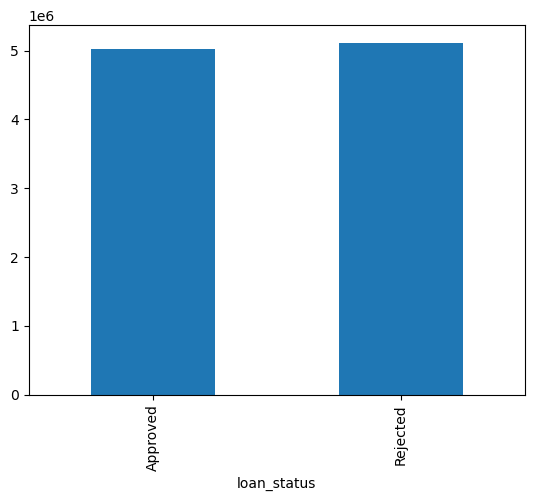

In [62]:
x.plot( kind = 'bar')

-------

### 5. How does loan amount vary between approved and rejected loans?

In [63]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [64]:
df['loan_amount'].describe()

count       4269.00
mean    15133450.46
std      9043362.98
min       300000.00
25%      7700000.00
50%     14500000.00
75%     21500000.00
max     39500000.00
Name: loan_amount, dtype: float64

In [65]:
df.groupby('loan_status').mean(numeric_only = True)['loan_amount']

loan_status
Approved   15247251.51
Rejected   14946063.24
Name: loan_amount, dtype: float64

In [66]:
approved_amount = df[df['loan_status'] == 'Approved']['loan_amount']

approved_amount

0       29900000
6       33000000
8        2200000
10      11200000
13      31500000
          ...   
4261     7500000
4263    12700000
4265    11300000
4267    12800000
4268    29700000
Name: loan_amount, Length: 2656, dtype: int64

In [67]:
rejected_amount = df[df['loan_status'] == 'Rejected']['loan_amount']

rejected_amount

1       12200000
2       29700000
3       30700000
4       24200000
5       13500000
          ...   
4258    22600000
4259    11500000
4262     3000000
4264     2300000
4266    23900000
Name: loan_amount, Length: 1613, dtype: int64

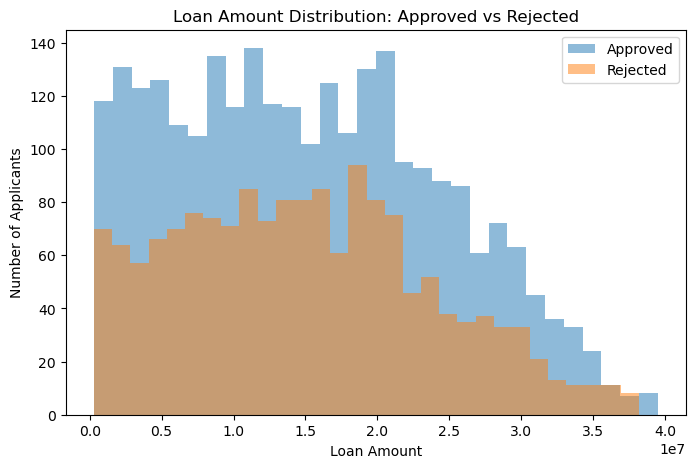

In [68]:
# Plot histogram

plt.figure(figsize = (8,5))

plt.hist( approved_amount, bins = 30, alpha = 0.5, label = 'Approved')
plt.hist( rejected_amount, bins = 30, alpha = 0.5, label = 'Rejected')

plt.title("Loan Amount Distribution: Approved vs Rejected")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.legend()

plt.show()

# Approved loans are more concentrated around moderate loan amounts

--------

### 6. Does Cibil Score strongly influence loan approval?

In [69]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [70]:
df['cibil_score'].describe()

count   4269.00
mean     599.94
std      172.43
min      300.00
25%      453.00
50%      600.00
75%      748.00
max      900.00
Name: cibil_score, dtype: float64

In [71]:
df.groupby('loan_status')['cibil_score'].mean()

loan_status
Approved   703.46
Rejected   429.47
Name: cibil_score, dtype: float64

In [72]:
# Separate loan amounts

approved_cibil = df[df['loan_status'] == 'Approved']['cibil_score']
rejected_cibil = df[df['loan_status'] == 'Rejected']['cibil_score']

In [73]:
approved_cibil

0       778
6       678
8       782
10      547
13      679
       ... 
4261    881
4263    865
4265    559
4267    780
4268    607
Name: cibil_score, Length: 2656, dtype: int64

In [74]:
rejected_cibil

1       417
2       506
3       467
4       382
5       319
       ... 
4258    346
4259    509
4262    540
4264    317
4266    457
Name: cibil_score, Length: 1613, dtype: int64

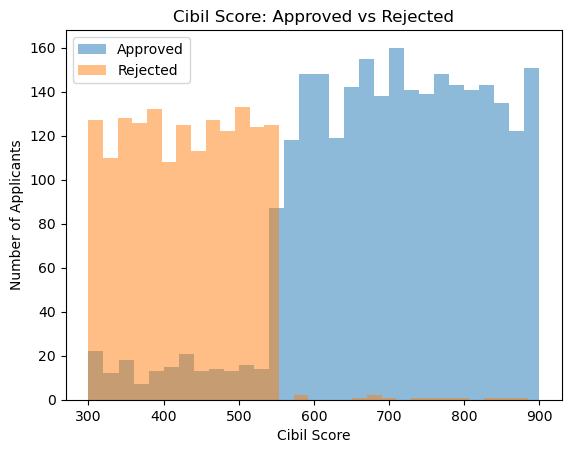

'The histogram clearly shows that approved loans are concentrated at higher CIBIL score ranges, \nwhile rejected loans are more common at lower CIBIL scores.\nThis confirms that credit score is a strong factor influencing loan approval.'

In [75]:
# Plot Histogram

plt.hist(approved_cibil, bins = 30, alpha = 0.5, label = 'Approved')
plt.hist(rejected_cibil, bins = 30, alpha = 0.5, label = 'Rejected')

plt.title("Cibil Score: Approved vs Rejected")
plt.xlabel("Cibil Score")
plt.ylabel("Number of Applicants")
plt.legend()


plt.show()

'''The histogram clearly shows that approved loans are concentrated at higher CIBIL score ranges, 
while rejected loans are more common at lower CIBIL scores.
This confirms that credit score is a strong factor influencing loan approval.'''

------

# 📈 Section 3: Data Visualization

### A. Compare Applicant Income vs Loan Amount (scatter plot)

In [76]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


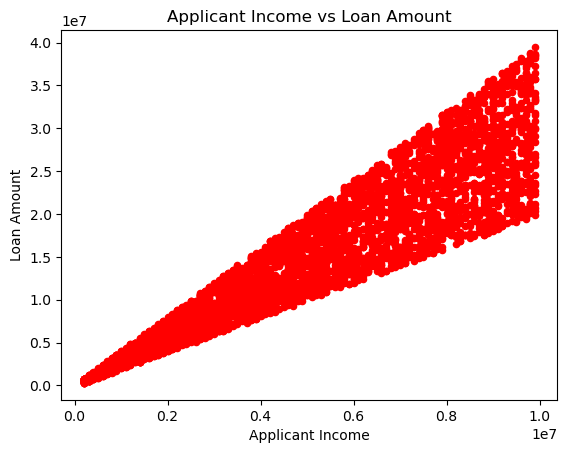

In [77]:
df.plot( x = 'income_annum', y = 'loan_amount', kind = 'scatter', color = 'red')
plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")



plt.show()

-------

---

### B. Show correlation heatmap of numerical features

In [78]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


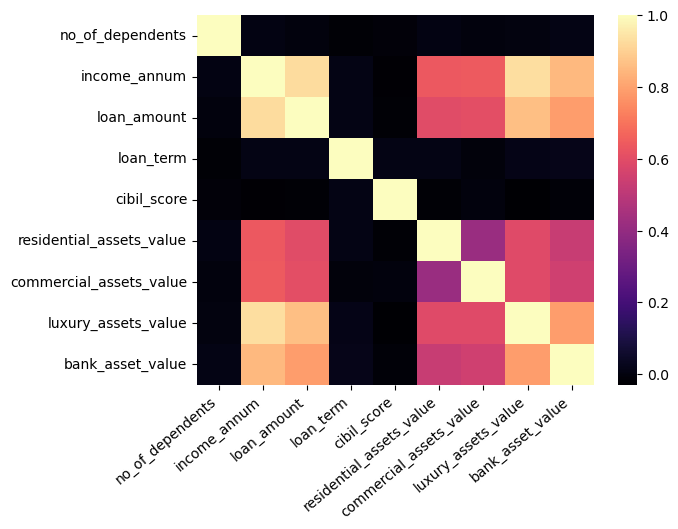

In [79]:
sns.heatmap( df.corr(numeric_only = True), cmap = 'magma' )

plt.xticks(rotation = 40, ha = 'right')

plt.show()

In [80]:
df['loan_amount'].corr(df['income_annum'])

np.float64(0.927469910987149)

In [81]:
df['luxury_assets_value'].corr(df['income_annum'])

np.float64(0.9291454207522588)

------------

# 🧹 Section 4: Data Cleaning & Feature Engineering

## Detect Outliers

In [82]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


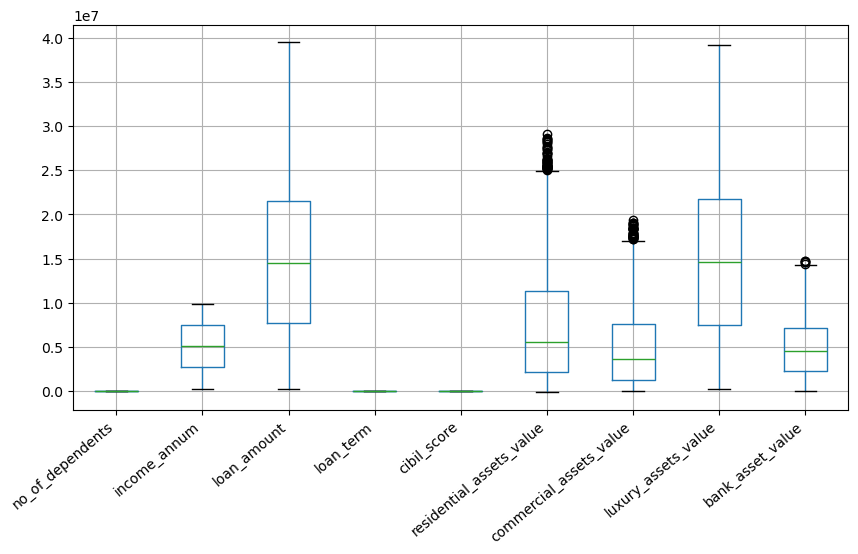

In [83]:
plt.figure(figsize = (10,5))

df.boxplot()

plt.xticks(rotation = 40, ha = 'right')

plt.show()

--------

### Remove Outliers

In [84]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [85]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [86]:
# Calculate Quartile

R_Q1 = df['residential_assets_value'].quantile(0.25)
R_Q3 = df['residential_assets_value'].quantile(0.75)

# Calculate IQR
IQR = R_Q3 - R_Q1

In [87]:
IQR

np.float64(9100000.0)

In [88]:
lower_limit = R_Q1 - 1.5 * IQR

upper_limit = R_Q3 + 1.5 * IQR

In [89]:
df = df[(df['residential_assets_value'] >= lower_limit) & (df['residential_assets_value'] <= upper_limit)]

In [90]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


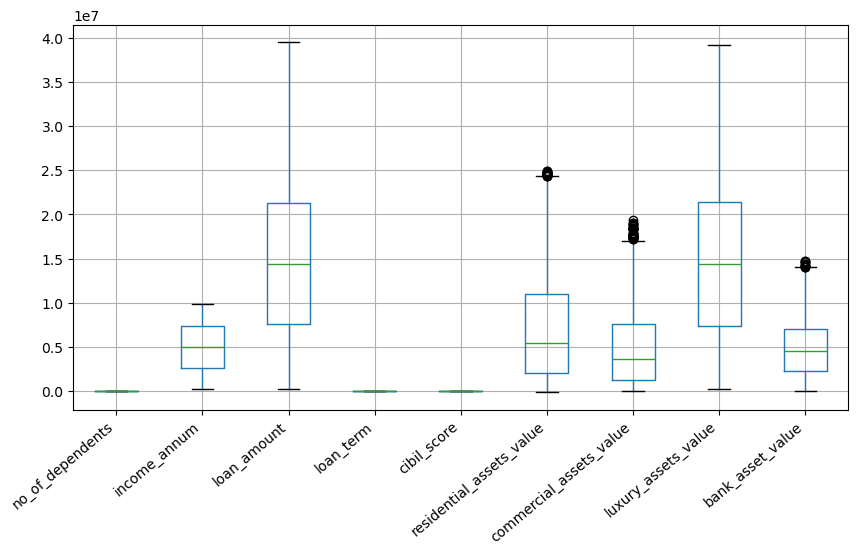

In [91]:
plt.figure(figsize = (10,5))

df.boxplot()

plt.xticks(rotation = 40, ha = 'right')

plt.show()

In [92]:
# Calculare Quartile

C_Q1 = df['commercial_assets_value'].quantile(0.25)

C_Q3 = df['commercial_assets_value'].quantile(0.75)


# Calculate IQR

C_IQR = C_Q3 - C_Q1

lower_limit = C_Q1 - 1.5 * C_IQR
upper_limit = C_Q3 + 1.5 * C_IQR

# Lower outlier limit

df = df[(df['commercial_assets_value'] >= lower_limit) & (df['commercial_assets_value'] <= upper_limit)]

In [93]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


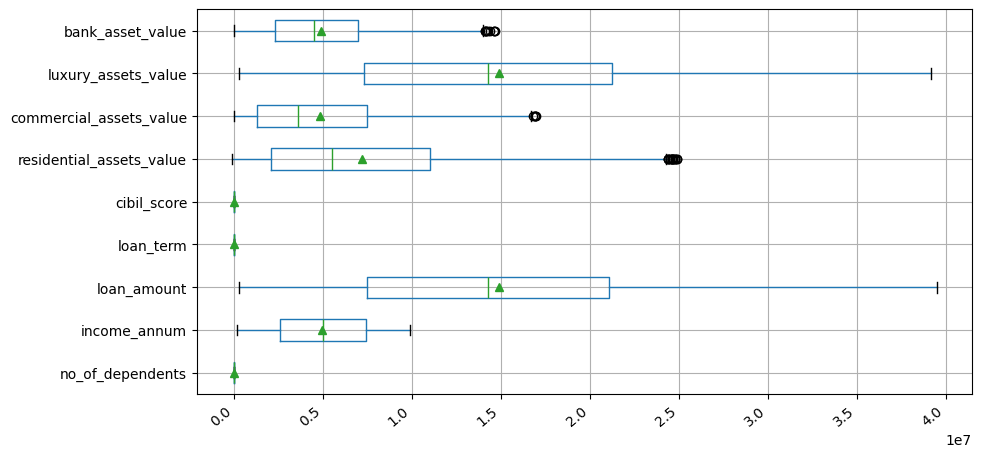

In [94]:
plt.figure(figsize = (10,5))

df.boxplot( showmeans = True , vert = False)

plt.xticks(rotation = 40, ha = 'right')

plt.show()

------

### Which features should be dropped (like Loan_ID)?

In [95]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [96]:
df = df.drop('loan_id', axis = 1)

In [97]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


------

### Convert categorical variables into numeric using Maping, Label Encoding & One Hot Encoding?

#### Mapping

In [98]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [99]:
df['loan_status'] = df['loan_status'].map({'Approved' : 1, 'Rejected' : 0})

In [100]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


#### Label Encoding

In [101]:
# Encode Binary Column

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['self_employed'] = le.fit_transform(df['self_employed'])

In [102]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


#### One-hot Encoding

In [103]:
df = pd.get_dummies(df, columns = ['education'])

# This avoids the dummy variable trap and keeps your model clean.

In [104]:
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False,True
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,False,True


-------

### Scale numerical features before model training

Feature scaling is essential for models like Logistic Regression and SVM, 
but not required for tree-based models. However, I applied scaling to ensure consistency and fair model comparison.


In [105]:
df.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False


In [106]:
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False,True
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,False,True


--------

# Model Building

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X = df.drop('loan_status', axis = 1)
y = df['loan_status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

models = {"Logistic Regression" : LogisticRegression(max_iter = 1000),
          "Decision Tree" : DecisionTreeClassifier(),
          "Random Forest": RandomForestClassifier() 
         }

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "Accuracy", accuracy_score(y_test, preds) )

Logistic Regression Accuracy 0.8160095579450418
Decision Tree Accuracy 0.96415770609319
Random Forest Accuracy 0.980884109916368


In [108]:
# ✅ Step 1: Split Features and Target

X = df.drop('loan_status', axis = 1)
y = df['loan_status']

In [109]:
# ✅ Step 2: Train–Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [110]:
# ✅ Step 3: Build Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier( n_estimators = 200, max_depth = 10, random_state = 39 )

In [111]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=39)

In [112]:
# ✅ Step 4: Make Predictions

y_pred = rf_model.predict(X_test)

In [113]:
# ✅ Step 5: Evaluate the Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred) * 100, "%")
print("Classification Report :", classification_report(y_test, y_pred))
print("Confusion Matrix :" , confusion_matrix(y_test, y_pred))

Accuracy : 97.0131421744325 %
Classification Report :               precision    recall  f1-score   support

           0       0.97      0.95      0.96       316
           1       0.97      0.98      0.98       521

    accuracy                           0.97       837
   macro avg       0.97      0.97      0.97       837
weighted avg       0.97      0.97      0.97       837

Confusion Matrix : [[300  16]
 [  9 512]]


In [114]:
# ✅ Step 6: Feature Importance

feature_importance = pd.Series( rf_model.feature_importances_, index = X.columns ).sort_values(ascending = False)

feature_importance

cibil_score                0.83
loan_term                  0.06
loan_amount                0.03
residential_assets_value   0.02
income_annum               0.02
commercial_assets_value    0.02
luxury_assets_value        0.02
bank_asset_value           0.01
no_of_dependents           0.01
self_employed              0.00
education_Graduate         0.00
education_Not Graduate     0.00
dtype: float64

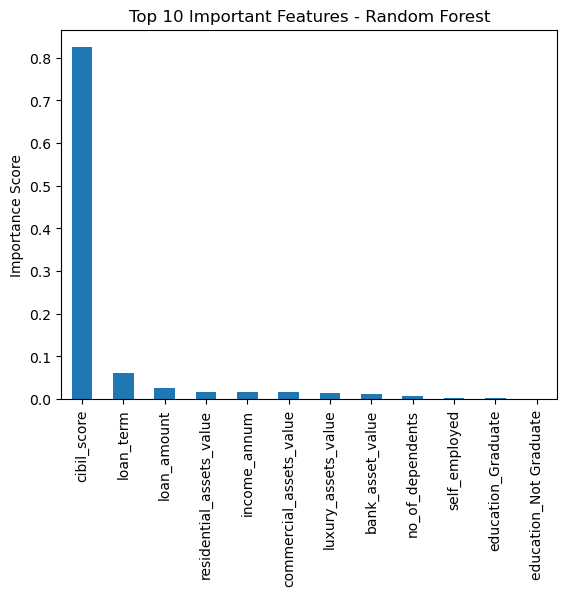

In [115]:
import matplotlib.pyplot as plt

feature_importance.plot(kind = 'bar')
plt.title("Top 10 Important Features - Random Forest")
plt.ylabel("Importance Score")
plt.show()

--------

# Model Prediction

In [116]:
df.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False


In [117]:
# For a new customer

new_applicant = {
    'no_of_dependents': 4,
    'self_employed': 1,    
    'income_annum': 600000,
    'loan_amount': 250000,
    'loan_term': 36,
    'cibil_score': 900,
    'residential_assets_value': 30,
    'commercial_assets_value': 0,
    'luxury_assets_value': 0,
    'bank_asset_value': 5000,
    'education_Graduate': 1,
    'education_Not Graduate':1,
}

new_df = pd.DataFrame([new_applicant])

In [118]:
new_df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
0,4,1,600000,250000,36,900,30,0,0,5000,1,1


In [119]:
prediction = rf_model.predict(new_df)

In [120]:
prediction

array([1])

------

# Save Model

In [121]:
import joblib

joblib.dump(rf_model, 'loan_approval_prediction.pkl')

['loan_approval_prediction.pkl']

In [122]:
# Load and Use :

loaded_model = joblib.load('loan_approval_prediction.pkl')

# future_predictions = loaded_model.predict(X_future)